# Timeseries forecast model
This notebook contains some timeserie models that aim to outperform the baseline model (see nb_baseline_model). The baseline model is a weighted average (seasonal) timeseries forecast for the next 4 quarters.

The data is limited to 2014 and onwards, so that we have a prediction for the last 10 years (2015-2025). This can be changed by adjusting the where clause in the SQL statement.

In the bottom section of the notebook the timeseries prediction is visualised for three groups of SBI codes:
- Total aggregated absenteeism (sbi=T001081)
- Absenteeism per SBI category (sbi lvl1, category A, B C etc.)
- Absenteeism per company size (sbi=WP19098,WP19091, WP19078)

## 1. Data preparation

In [1]:
import sys
import os
from pathlib import Path
# Add project root to sys.path to allow imports from src
sys.path.append(str(Path(os.getcwd()).parent.parent))

from sqlalchemy import create_engine
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import statsmodels
from statsmodels.tsa.seasonal import STL                    # STL stays here ✅
from statsmodels.tsa.forecasting.stl import STLForecast     # STLForecast is here ✅
from statsmodels.tsa.arima.model import ARIMA               # also updated
from statsmodels.tsa.exponential_smoothing.ets import ETSModel

from src.config import DIR_DB_SILVER, DIR_DB_GOLD
from src.utils.m_nb_results_to_gold_export import f_nb_results_to_gold_export, f_list_gold_tables
from src.utils.m_query_database import f_query_database

# Settings — pandas display options 
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)       # Show all columns
pd.set_option("display.max_rows", 20)            # Show 20 rows
pd.set_option("display.width", 10000)            # Prevent truncation due to width limit
pd.set_option("display.float_format", "{:.2f}".format)

# Get baseline model results from gold
query = """ SELECT * FROM prediction_baseline_total"""
df_baseline_total = f_query_database(DIR_DB_GOLD, query, "pandas")
df_baseline_total["period_enddate"] = pd.to_datetime(df_baseline_total["period_enddate"])
print(f"✅ Success! Loaded {len(df_baseline_total)} rows.")

# Get same dataset as baseline model
# SQL Query to extract and format absenteeism data
query = """ 
SELECT 
    Perioden as timeperiod_text, 
    BedrijfskenmerkenSBI2008  as sbi_code,
    BedrijfskenmerkenSBI2008_Title as sbi_title,
    DATE(
        printf('%s-%s-01', 
            substr(Perioden, 1, 4), 
            CASE substr(Perioden, 7, 2)
                WHEN '01' THEN '01'
                WHEN '02' THEN '04'
                WHEN '03' THEN '07'
                WHEN '04' THEN '10'
            END
        ), 
        '+3 months', 
        '-1 day'
    ) AS period_enddate,
    CAST(substr(Perioden, 1, 4) as INTEGER) as "year",
    CAST(substr(Perioden, 8, 1) as INTEGER) as "quarter",
    CAST(Ziekteverzuimpercentage_1 AS REAL) as absenteeism_perc
FROM "80072ned_silver"
WHERE Perioden NOT LIKE '%JJ%' 
AND substr(Perioden, 1, 4) >= '2012'
order by sbi_code, Period_enddate asc
"""
df_org = f_query_database(DIR_DB_SILVER, query, "pandas")
print(f"✅ Success! Loaded {len(df_org)} rows.")

# --- Type Casting ---
# parse_dates already handles period_enddate; cast remaining columns explicitly
df_org["year"] = df_org["year"].astype(int)
df_org["quarter"] = df_org["quarter"].astype(int)
df_org["absenteeism_perc"] = pd.to_numeric(df_org["absenteeism_perc"], errors="coerce")
df_org["period_enddate"] = pd.to_datetime(df_org["period_enddate"])
# Keep a clean copy as df_modified (mirrors the original variable name)
df_modified = df_org.copy()

# --- Split into three DataFrames for different analyses ---
df_total = (
    df_modified[df_modified["sbi_code"] == "T001081"]
    .copy()
    .sort_values("period_enddate")
    .reset_index(drop=True)
)

df_sbi_lvl1 = (
    df_modified[df_modified["sbi_title"].str.upper().str.contains(r"^[A-U]\s", regex=True)]
    .copy()
    .reset_index(drop=True)
)

df_compsize = (
    df_modified[df_modified["sbi_code"].isin(["WP19098", "WP19091", "WP19078"])]
    .copy()
    .reset_index(drop=True)
)

# Quick look at the most recent rows
print(df_total.sort_values("period_enddate", ascending=False).head())

✅ Success! Loaded 55 rows.
✅ Success! Loaded 2145 rows.
   timeperiod_text sbi_code                          sbi_title period_enddate  year  quarter  absenteeism_perc
54        2025KW03  T001081  A-U Alle economische activiteiten     2025-09-30  2025        3              5.10
53        2025KW02  T001081  A-U Alle economische activiteiten     2025-06-30  2025        2              5.20
52        2025KW01  T001081  A-U Alle economische activiteiten     2025-03-31  2025        1              5.80
51        2024KW04  T001081  A-U Alle economische activiteiten     2024-12-31  2024        4              5.40
50        2024KW03  T001081  A-U Alle economische activiteiten     2024-09-30  2024        3              4.90


### 2. STL (Seasonal-Trend decomposition using LOESS) 
Refresher: STL decomposes your time series into three components:
- *Trend:* the long-term direction
- *Seasonality:* repeating quarterly patterns
- *Residual:* what's left over (noise)

Why use STL for absenteeism? Absenteeism has strong seasonality, EADE shows a clear trend, and some noise (i.e. covid). Our baseline model(year-on-year moving average) implicitly captures seasonality but ignores trend changes. STL handles both explicitly.

STLForecast approach: first decompose the series using STL, then a separate model (like ARIMA or ETS) forecasts the trend+residual component. The seasonal component is then reattached to produce final forecasts.

In [35]:
# --- Step 2: Prepare df_total as a proper time series ---
# Set period_enddate as the index — STL needs a datetime index
df_ts = (
    df_total
    .set_index("period_enddate")["absenteeism_perc"]
    .asfreq("QE")  # QE = Quarter End frequency; enforces regularity
)
# What asfreq("QE") does: It forces pandas to recognize this as quarterly data ending on the last day of each quarter. 
# If any quarter is missing, it inserts a NaN — which alerts you immediately rather than silently corrupting your model. 
# If you have NaNs, you'd interpolate: ts = ts.interpolate(method="time").

# Quick sanity check
print(f"Time series length: {len(df_ts)} quarters")
print(f"Start: {df_ts.index.min().date()}  |  End: {df_ts.index.max().date()}")
print(f"Missing values: {df_ts.isna().sum()}")
print(df_ts.tail(8))

Time series length: 55 quarters
Start: 2012-03-31  |  End: 2025-09-30
Missing values: 0
period_enddate
2023-12-31   5.50
2024-03-31   5.50
2024-06-30   5.10
2024-09-30   4.90
2024-12-31   5.40
2025-03-31   5.80
2025-06-30   5.20
2025-09-30   5.10
Freq: QE-DEC, Name: absenteeism_perc, dtype: float64


### 2.1 Visual exploration
A quick visual inspection to see the trend and seasonal pattern

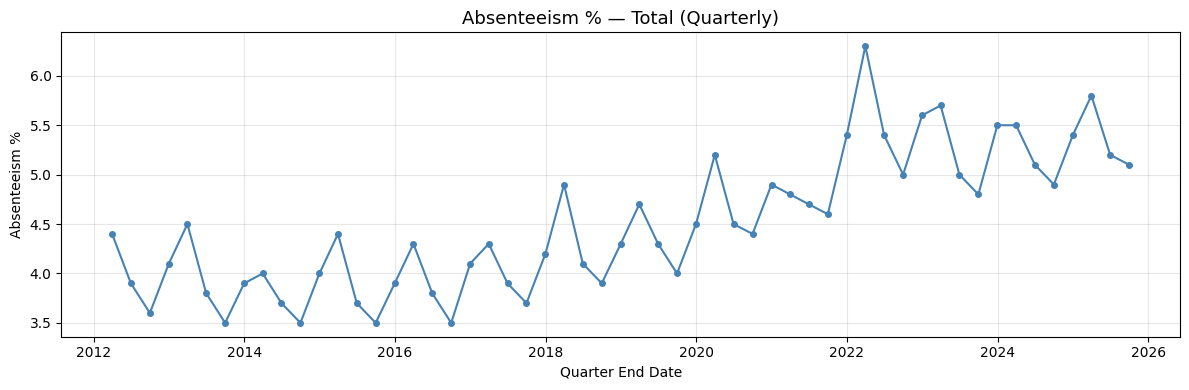

In [36]:
# --- Step 3: Visualize the raw series ---

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_ts.index, df_ts.values, marker="o", linewidth=1.5, markersize=4, color="steelblue")
ax.set_title("Absenteeism % — Total (Quarterly)", fontsize=13)
ax.set_ylabel("Absenteeism %")
ax.set_xlabel("Quarter End Date")
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Component magnitudes (std dev):
  Seasonal:  0.3274
  Trend:     0.6075
  Residual:  0.1518


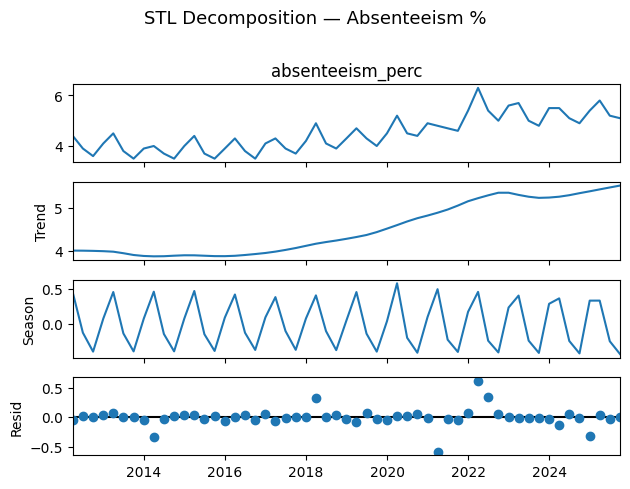

In [37]:
# --- Step 4: STL Decomposition (inspect only, no forecast yet) ---

stl = STL(
    df_ts,
    period=4,        # 4 quarters = 1 year of seasonality
    seasonal=7,      # seasonal smoother window — must be odd, >= 7; 7 is a good start
    trend=None,      # None = auto-calculated (roughly 1.5 * period / (1 - 1/seasonal), rounded up to odd)
    robust=True      # robust=True reduces influence of outliers (like COVID spikes)
)
stl_result = stl.fit()
# Print the component magnitudes — useful for understanding relative importance
print("Component magnitudes (std dev):")
print(f"  Seasonal:  {stl_result.seasonal.std():.4f}")
print(f"  Trend:     {stl_result.trend.std():.4f}")
print(f"  Residual:  {stl_result.resid.std():.4f}")

stl_result.plot()
plt.suptitle("STL Decomposition — Absenteeism %", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

### 2.2 STL Forecast
We combine the previous STL decomposition with an ETS forecasting model for the trend+residual. 

**Note:** The STL Decomposition in the previous step is NOT directly used by following STLForecast function.
That's because STLForecast runs its own internal STL decomposition "under the hood". The previous STL + .fit() is purely for visual inspection / diagnostic. STLForecast takes the same df_ts as input and then internally runs STL itself as part of its fitting process.

In [38]:
# quarters to forecast, baseline model is year-on-year, so N_forecast is 4 quarters.
n_forecast = 4

stl_forecast_model = STLForecast(
    df_ts,
    model=ETSModel,           # ETS handles trend extrapolation well
    model_kwargs={
        "error": "add",       # additive error
        "trend": "add",       # additive trend (try "add" first; use None if trend is flat)
        "seasonal": None,     # None! STL already handles seasonality — don't double-count it
        "damped_trend": True  # dampen the trend so it doesn't extrapolate wildly
    },
    period=4,
    seasonal=7,
    robust=True               # consistent with your decomposition above
)

stl_fit = stl_forecast_model.fit()
forecast = stl_fit.forecast(n_forecast)

print("Forecasted absenteeism % (next 4 quarters):")
print(forecast.round(2))

Forecasted absenteeism % (next 4 quarters):
2025-12-31   5.86
2026-03-31   5.87
2026-06-30   5.30
2026-09-30   5.12
Freq: QE-DEC, dtype: float64


#### Visualisation
Historical data + forecast

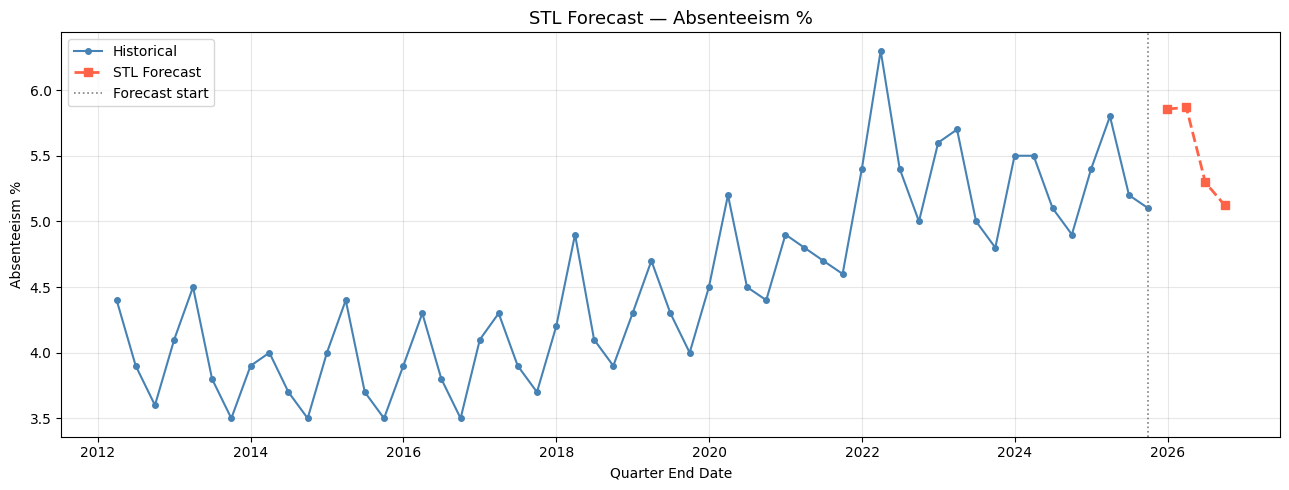

In [39]:
fig, ax = plt.subplots(figsize=(13, 5))

# Historical
ax.plot(df_ts.index, df_ts.values, marker="o", linewidth=1.5, markersize=4,
        color="steelblue", label="Historical")
# Forecast
ax.plot(forecast.index, forecast.values, marker="s", linewidth=2,
        markersize=6, color="tomato", linestyle="--", label="STL Forecast")
# Visual separator
ax.axvline(df_ts.index[-1], color="gray", linestyle=":", linewidth=1.2, label="Forecast start")

ax.set_title("STL Forecast — Absenteeism %", fontsize=13)
ax.set_ylabel("Absenteeism %")
ax.set_xlabel("Quarter End Date")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Walk-forward evaluation
Compare STL vs. the baseline model on the same held-out periods using MAE, using walk-forward (rolling) validation. <br>
Why walk-forward and not a simple train/test split? Time series data has a strict rule: the future cannot influence the past. A standard train/test split randomly shuffles data, which would mean training on 2022 data to predict 2019 — that's data leakage. Walk-forward validation enforces temporal integrity by always training only on data that would have been available at that point in time.

The mental model
Think of it like a scientist who can only use information available today to make a prediction about tomorrow. Once tomorrow arrives and the actual value is known, they record the error, move their "today" forward by one step, and repeat.
────────────────────────────────────────────────────────────────►  time

FOLD 1:  [■ ■ ■ ■ ■ ■ ■ ■ ■ ■ ■ ■]  □
          ↑ training data           ↑ predict this one point

FOLD 2:  [■ ■ ■ ■ ■ ■ ■ ■ ■ ■ ■ ■ ■]  □
          ↑ training data grows      ↑ predict this one point

FOLD 3:  [■ ■ ■ ■ ■ ■ ■ ■ ■ ■ ■ ■ ■ ■]  □
          ↑ training data grows again ↑ predict this one point

         ■ = training data
         □ = the one point being predicted (never seen during training)
         
At each fold, the training window grows by one observation and the model is retrained from scratch. The prediction is made for the very next point only.

In [55]:
# --- Prepare baseline_series from df_baseline_total for alignment ---
baseline_series = (
    df_baseline_total
    .set_index("period_enddate")["baseline_prediction"]
    .asfreq("QE")
)

# --- Now run STL walk-forward over the SAME rows where baseline is valid ---
valid_idx = baseline_series.dropna().index  # only rows where baseline could predict

actuals = []
stl_preds = []
baseline_preds = []

for date in valid_idx:
    i = df_ts.index.get_loc(date)
    
    if i < 12:  # STL needs minimum history; skip very early rows
        continue

    train = df_ts.iloc[:i]
    actual_val = df_ts.iloc[i]

    # STL prediction
    try:
        fold_model = STLForecast(
            train,
            model=ETSModel,
            model_kwargs={
                "error": "add",
                "trend": "add",
                "seasonal": None,
                "damped_trend": True
            },
            period=4,
            seasonal=7,
            robust=True
        )
        fold_fit = fold_model.fit()
        stl_pred = fold_fit.forecast(1).iloc[0]
    except Exception as e:
        print(f"STL failed at {date}: {e}")
        stl_pred = np.nan

    actuals.append(actual_val)
    stl_preds.append(stl_pred)
    baseline_preds.append(baseline_series[date])

# --- MAE comparison on identical evaluation window ---
actuals = np.array(actuals)
stl_preds = np.array(stl_preds)
baseline_preds = np.array(baseline_preds)

mae_stl = np.nanmean(np.abs(actuals - stl_preds))
mae_baseline = np.mean(np.abs(actuals - baseline_preds))

print(f"\n{'='*40}")
print(f"Evaluation window: {len(actuals)} quarters")
print(f"MAE — STL Forecast:   {mae_stl:.4f}")
print(f"MAE — Baseline:       {mae_baseline:.4f}")
print(f"Improvement:          {(mae_baseline - mae_stl) / mae_baseline * 100:.1f}%")


Evaluation window: 43 quarters
MAE — STL Forecast:   0.2169
MAE — Baseline:       0.2961
Improvement:          26.7%


### Visualisation

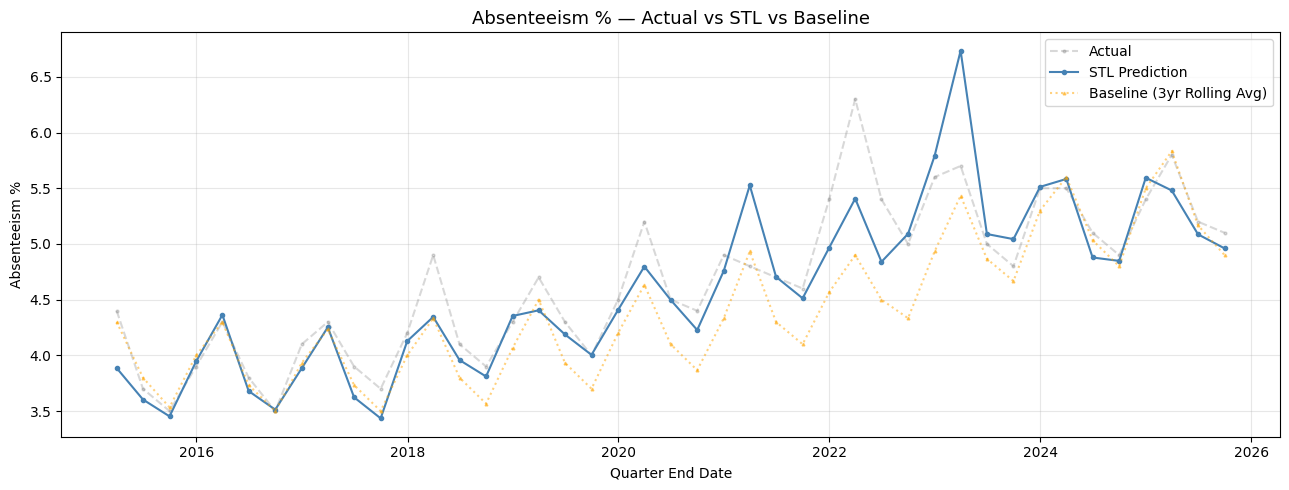

In [54]:
# --- Build results DataFrame for plotting ---
df_results = pd.DataFrame({
    "period_enddate": valid_idx[len(valid_idx) - len(actuals):],  # align dates to evaluated window
    "actual":         actuals,
    "stl_prediction": stl_preds,
    "baseline":       baseline_preds
})

# --- Plot ---
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(df_results["period_enddate"], df_results["actual"],
        marker="o", linewidth=1.5, markersize=2, color="grey", linestyle="--", alpha=0.3, label="Actual")

ax.plot(df_results["period_enddate"], df_results["stl_prediction"],
        marker="o", linewidth=1.5, markersize=3, color="steelblue", label="STL Prediction")

ax.plot(df_results["period_enddate"], df_results["baseline"],
        marker="^", linewidth=1.5, markersize=2, color="orange", linestyle=":", alpha=0.5, label="Baseline (3yr Rolling Avg)")

ax.set_title("Absenteeism % — Actual vs STL vs Baseline", fontsize=13)
ax.set_ylabel("Absenteeism %")
ax.set_xlabel("Quarter End Date")
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()